# TP12 — Feature Engineering : Z-Score Machine Pré-Calculé

TP10 a montré qu'appliquer un z-score machine **à l'entraînement** crée un domain shift en GroupKFold :  
la machine val n'a pas de stats dans le fold → fallback flotte → référentiels incompatibles → CV = 0.5580.

La solution correcte : calculer les z-scores sur l'**historique complet** de chaque machine, **avant** le split train/val/test.  
Ainsi, chaque machine dispose toujours de ses stats propres, même en validation GroupKFold.

| Modèle | Feature engineering | PR-AUC CV | PR-AUC test |
|--------|---------------------|-----------|-------------|
| B9-GKF (TP9)  | 69 features, HP B8       | 0.7792 ± 0.1772 | 0.8595 |
| B11-GKF (TP11)| 69 features, HP Optuna GKF | 0.7839 ± 0.1891 | 0.8799 |
| **B12-GKF**   | **69 + zscore_machine complets, HP B11** | ? | ? |

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Données — Inspection des features zscore_machine existantes

In [2]:
url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost", port=5432, database="indusense_db",
)
engine = create_engine(url)
df = pd.read_sql(
    "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start",
    engine
)

TARGET = "label_failure_next_24h"
LEAKAGE_COLS = [
    "machine_id", "ingestion_batch_id", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h", "label_failure_next_48h",
    TARGET, "feature_row_id",
]
FEATURE_COLS = [c for c in df.columns if c not in LEAKAGE_COLS]

# Séparer les features zscore_machine existantes des features brutes
zmachine_existing = [c for c in FEATURE_COLS if "zscore_machine" in c.lower() or "zmachine" in c.lower()]
raw_features      = [c for c in FEATURE_COLS if c not in zmachine_existing]

print(f"Dataset : {df.shape[0]:,} lignes | Colonnes totales : {df.shape[1]}")
print(f"Features totales       : {len(FEATURE_COLS)}")
print(f"  dont zscore_machine  : {len(zmachine_existing)}")
print(f"  dont raw/autres      : {len(raw_features)}")
print(f"\nFeatures zscore_machine existantes :")
for f in zmachine_existing:
    print(f"  {f}")

Dataset : 132,940 lignes | Colonnes totales : 79
Features totales       : 69
  dont zscore_machine  : 2
  dont raw/autres      : 67

Features zscore_machine existantes :
  temp_zscore_machine
  pressure_zscore_machine


## 3. Identification des features raw sans équivalent zscore_machine

Pour chaque feature raw, on vérifie s'il existe déjà une version `_zscore_machine`.  
Les features sans équivalent recevront un z-score calculé sur l'historique complet machine.

In [3]:
# Extraire les noms de base des features zscore_machine existantes
# Convention attendue : {base}_zscore_machine ou {base}_zmachine
zmachine_bases = set()
for col in zmachine_existing:
    base = col.replace("_zscore_machine", "").replace("_zmachine", "")
    zmachine_bases.add(base)

# Features raw qui n'ont pas encore d'équivalent zscore_machine
raw_missing = [c for c in raw_features if c not in zmachine_bases]

print(f"Features raw sans équivalent zscore_machine : {len(raw_missing)}")
if raw_missing:
    print("\nListe :")
    for f in raw_missing:
        print(f"  {f}")
else:
    print("\nToutes les features raw ont déjà un équivalent zscore_machine.")

Features raw sans équivalent zscore_machine : 67

Liste :
  temp_mean_24h
  temp_max_24h
  temp_std_24h
  pressure_mean_24h
  pressure_std_24h
  incident_count_prev_24h
  incident_max_severity_prev_24h
  temp_mean_1h
  temp_max_1h
  temp_std_1h
  pressure_mean_1h
  pressure_max_1h
  pressure_std_1h
  voltage_mean_1h
  rotation_mean_1h
  pieces_produced_sum_1h
  temp_mean_6h
  temp_max_6h
  temp_std_6h
  pressure_mean_6h
  pressure_max_6h
  pressure_std_6h
  voltage_mean_6h
  voltage_std_6h
  rotation_mean_6h
  rotation_std_6h
  temp_mean_12h
  temp_max_12h
  temp_std_12h
  pressure_mean_12h
  pressure_max_12h
  pressure_std_12h
  voltage_mean_12h
  voltage_std_12h
  rotation_mean_12h
  rotation_std_12h
  pressure_max_24h
  voltage_mean_24h
  voltage_std_24h
  rotation_mean_24h
  rotation_std_24h
  temp_delta_1h
  temp_delta_3h
  temp_trend_6h
  pressure_delta_1h
  pressure_delta_3h
  pressure_trend_6h
  voltage_delta_1h
  voltage_delta_3h
  voltage_trend_6h
  rotation_delta_1h
  rotati

## 4. Pré-calcul des z-scores manquants — Historique complet machine

**Principe clé** : les stats (µ, σ) sont calculées sur la **totalité des données** de chaque machine,  
avant tout split. La machine val aura toujours ses stats propres en GroupKFold — aucun domain shift.

```
TP10 (mauvais) : stats calculées sur fold train → machine val = fallback flotte → domain shift
TP12 (correct) : stats calculées sur historique complet → machine val = ses propres stats → pas de shift
```

In [4]:
def compute_machine_zscores(df_full, raw_cols, suffix="_zmachine"):
    """
    Calcule le z-score par machine sur l'historique complet (df_full).
    Fallback flotte pour les rares machines avec σ=0 ou sans données.
    Retourne un DataFrame avec les nouvelles colonnes uniquement.
    """
    # Statistiques par machine sur l'ensemble du dataset
    machine_stats = df_full.groupby("machine_id")[raw_cols].agg(["mean", "std"])
    fleet_mu  = df_full[raw_cols].mean()
    fleet_sig = df_full[raw_cols].std().replace(0, 1)

    result = {}
    m_ids = df_full["machine_id"].reset_index(drop=True)

    for col in raw_cols:
        new_col = f"{col}{suffix}"
        mu  = m_ids.map(machine_stats[col]["mean"]).fillna(fleet_mu[col]).astype(float)
        sig = m_ids.map(machine_stats[col]["std"]).fillna(fleet_sig[col]).replace(0, 1).astype(float)
        raw_vals = df_full[col].apply(pd.to_numeric, errors="coerce").values
        result[new_col] = (raw_vals - mu.values) / sig.values

    return pd.DataFrame(result, index=df_full.index)


if raw_missing:
    print(f"Calcul des z-scores machine pour {len(raw_missing)} features...")
    new_zmachine = compute_machine_zscores(df, raw_missing)
    df_aug = pd.concat([df, new_zmachine], axis=1)
    FEATURE_COLS_AUG = FEATURE_COLS + list(new_zmachine.columns)
    print(f"Features originales : {len(FEATURE_COLS)}")
    print(f"Features augmentées : {len(FEATURE_COLS_AUG)} (+{len(new_zmachine.columns)} zscore_machine)")
else:
    # Toutes les features raw ont déjà un équivalent → pas de calcul supplémentaire
    print("Toutes les features ont déjà un zscore_machine — utilisation du dataset original.")
    df_aug = df.copy()
    FEATURE_COLS_AUG = FEATURE_COLS

# Vérification rapide : distribution des z-scores calculés
if raw_missing:
    sample_col = list(new_zmachine.columns)[0]
    print(f"\nVérification {sample_col} :")
    print(f"  mean={new_zmachine[sample_col].mean():.4f} (attendu ≈ 0)")
    print(f"  std ={new_zmachine[sample_col].std():.4f} (attendu ≈ 1)")
    by_machine = df_aug.groupby("machine_id")[sample_col].mean()
    print(f"  mean par machine :\n{by_machine.round(4)}")

Calcul des z-scores machine pour 67 features...
Features originales : 69
Features augmentées : 136 (+67 zscore_machine)

Vérification temp_mean_24h_zmachine :
  mean=0.0000 (attendu ≈ 0)
  std =0.9999 (attendu ≈ 1)
  mean par machine :
machine_id
MACH-01   -0.0
MACH-02   -0.0
MACH-03    0.0
MACH-04    0.0
MACH-05   -0.0
MACH-06    0.0
MACH-07   -0.0
MACH-08    0.0
MACH-09    0.0
MACH-10    0.0
MACH-11    0.0
MACH-12   -0.0
MACH-13    0.0
MACH-14   -0.0
MACH-15   -0.0
Name: temp_mean_24h_zmachine, dtype: float64


## 5. Évaluation B12-GKF — GroupKFold(15 machines)

In [5]:
# Hyperparamètres B11 (meilleurs — Optuna GroupKFold TP11)
B11_PARAMS = {
    "n_estimators":     287,
    "max_depth":        9,
    "learning_rate":    0.0289,
    "subsample":        0.825,
    "colsample_bytree": 0.574,
    "min_child_weight": 11,
    "reg_alpha":        0.0192,
    "reg_lambda":       0.623,
    "random_state":     RANDOM_STATE,
    "verbosity":        0,
}

# Données train+val avec features augmentées
trainval = df_aug[df_aug["split_set"].isin(["train", "validation"])].copy()
test     = df_aug[df_aug["split_set"] == "test"].copy()

X_tv   = trainval[FEATURE_COLS_AUG]
y_tv   = trainval[TARGET]
groups = trainval["machine_id"]
X_test, y_test = test[FEATURE_COLS_AUG], test[TARGET]

N_MACHINES = groups.nunique()
SPW_GLOBAL = round((y_tv == 0).sum() / (y_tv == 1).sum(), 2)
print(f"Features : {len(FEATURE_COLS_AUG)} | Machines : {N_MACHINES}")
print(f"Train+val : {len(X_tv):,} | Test : {len(X_test):,}")
print(f"scale_pos_weight global : {SPW_GLOBAL}")

# Référence B9-GKF (par machine)
B9_SCORES = {
    "MACH-07": 0.329, "MACH-05": 0.568, "MACH-13": 0.639, "MACH-02": 0.664,
    "MACH-03": 0.707, "MACH-10": 0.760, "MACH-12": 0.761, "MACH-09": 0.784,
    "MACH-14": 0.793, "MACH-04": 0.874, "MACH-01": 0.878, "MACH-06": 0.917,
    "MACH-08": 0.955, "MACH-15": 1.000, "MACH-11": 1.000,
}
B11_SCORES = {
    "MACH-07": 0.387, "MACH-02": 0.449, "MACH-01": 0.936,
    "MACH-06": 0.947, "MACH-08": 1.000, "MACH-11": 1.000, "MACH-15": 1.000,
}

Features : 136 | Machines : 15
Train+val : 112,996 | Test : 19,944
scale_pos_weight global : 27.12


In [6]:
gkf = GroupKFold(n_splits=N_MACHINES)
fold_results = []

for fold_i, (tr_idx, vl_idx) in enumerate(gkf.split(X_tv, y_tv, groups)):
    machine_val = groups.iloc[vl_idx].unique()[0]
    X_tr, y_tr = X_tv.iloc[tr_idx], y_tv.iloc[tr_idx]
    X_vl, y_vl = X_tv.iloc[vl_idx], y_tv.iloc[vl_idx]

    spw = round((y_tr == 0).sum() / max((y_tr == 1).sum(), 1), 2)
    params = {**B11_PARAMS, "scale_pos_weight": spw}

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(**params)),
    ])
    pipe.fit(X_tr, y_tr)

    n_pos  = int(y_vl.sum())
    y_prob = pipe.predict_proba(X_vl)[:, 1]
    pr_auc = average_precision_score(y_vl, y_prob) if n_pos >= 2 else float("nan")

    fold_results.append({
        "machine": machine_val,
        "n_pos":   n_pos,
        "pr_auc":  round(pr_auc, 4),
    })
    print(f"Fold {fold_i+1:2d} | {machine_val:<10} | n_pos={n_pos:4d} | PR-AUC={pr_auc:.4f}")

results_df = pd.DataFrame(fold_results)
valid = results_df.dropna(subset=["pr_auc"]).copy()
valid["b9"]    = valid["machine"].map(B9_SCORES)
valid["b11"]   = valid["machine"].map(B11_SCORES)
valid["delta_b9"]  = (valid["pr_auc"] - valid["b9"]).round(4)
valid["delta_b11"] = (valid["pr_auc"] - valid["b11"]).round(4)

cv_mean = valid["pr_auc"].mean()
cv_std  = valid["pr_auc"].std()
print(f"\nPR-AUC CV moyen : {cv_mean:.4f} ± {cv_std:.4f}")
print(f"Δ vs B9-GKF     : {cv_mean - 0.7792:+.4f}")
print(f"Δ vs B11-GKF    : {cv_mean - 0.7839:+.4f}")

Fold  1 | MACH-15    | n_pos=  71 | PR-AUC=1.0000
Fold  2 | MACH-01    | n_pos= 491 | PR-AUC=0.9859
Fold  3 | MACH-12    | n_pos= 213 | PR-AUC=0.7280
Fold  4 | MACH-07    | n_pos=  71 | PR-AUC=0.2801
Fold  5 | MACH-05    | n_pos= 189 | PR-AUC=0.6263
Fold  6 | MACH-11    | n_pos=  48 | PR-AUC=1.0000
Fold  7 | MACH-10    | n_pos= 292 | PR-AUC=0.7850
Fold  8 | MACH-14    | n_pos= 314 | PR-AUC=0.7981
Fold  9 | MACH-13    | n_pos= 809 | PR-AUC=0.6556
Fold 10 | MACH-04    | n_pos= 190 | PR-AUC=0.7694
Fold 11 | MACH-02    | n_pos=  72 | PR-AUC=0.2770
Fold 12 | MACH-06    | n_pos= 338 | PR-AUC=0.9137
Fold 13 | MACH-08    | n_pos=  48 | PR-AUC=1.0000
Fold 14 | MACH-03    | n_pos= 632 | PR-AUC=0.7343
Fold 15 | MACH-09    | n_pos= 240 | PR-AUC=0.6663

PR-AUC CV moyen : 0.7480 ± 0.2315
Δ vs B9-GKF     : -0.0312
Δ vs B11-GKF    : -0.0359


## 6. Modèle final B12 — test

In [7]:
pipe_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(**{**B11_PARAMS, "scale_pos_weight": SPW_GLOBAL})),
])
pipe_final.fit(X_tv, y_tv)

pr_train = average_precision_score(y_tv,   pipe_final.predict_proba(X_tv)[:, 1])
pr_test  = average_precision_score(y_test, pipe_final.predict_proba(X_test)[:, 1])
roc_test = roc_auc_score(y_test,           pipe_final.predict_proba(X_test)[:, 1])
f1_test  = f1_score(y_test,                pipe_final.predict(X_test), zero_division=0)
delta    = round(pr_train - cv_mean, 4)

print("=== Modèle final B12-GKF ===")
print(f"  Features           : {len(FEATURE_COLS_AUG)} ({len(FEATURE_COLS_AUG) - len(FEATURE_COLS):+d} vs B11)")
print(f"  PR-AUC train       : {pr_train:.4f}")
print(f"  PR-AUC CV moyen    : {cv_mean:.4f} ± {cv_std:.4f}")
print(f"  PR-AUC test        : {pr_test:.4f}")
print(f"  ROC-AUC test       : {roc_test:.4f}")
print(f"  F1 test            : {f1_test:.4f}")
print(f"  Overfitting Δ      : {delta:.4f}")

print("\n=== Comparaison globale ===")
print(f"  {'Modèle':<14} {'Features':>10} {'PR-AUC CV':>12} {'PR-AUC test':>13} {'Δ CV':>8}")
print("  " + "-"*65)
print(f"  {'B9-GKF':<14} {'69':>10} {'0.7792 ±0.18':>12} {'0.8595':>13} {'ref':>8}")
print(f"  {'B11-GKF':<14} {'69':>10} {'0.7839 ±0.19':>12} {'0.8799':>13} {'+0.0047':>8}")
print(f"  {'B12-GKF':<14} {str(len(FEATURE_COLS_AUG)):>10} {f'{cv_mean:.4f} ±{cv_std:.2f}':>12} {pr_test:>13.4f} {cv_mean-0.7792:>+8.4f}")

=== Modèle final B12-GKF ===
  Features           : 136 (+67 vs B11)
  PR-AUC train       : 0.9998
  PR-AUC CV moyen    : 0.7480 ± 0.2315
  PR-AUC test        : 0.8487
  ROC-AUC test       : 0.9949
  F1 test            : 0.7744
  Overfitting Δ      : 0.2518

=== Comparaison globale ===
  Modèle           Features    PR-AUC CV   PR-AUC test     Δ CV
  -----------------------------------------------------------------
  B9-GKF                 69 0.7792 ±0.18        0.8595      ref
  B11-GKF                69 0.7839 ±0.19        0.8799  +0.0047
  B12-GKF               136 0.7480 ±0.23        0.8487  -0.0312


## 7. Visualisation — Comparaison par machine B9 / B11 / B12

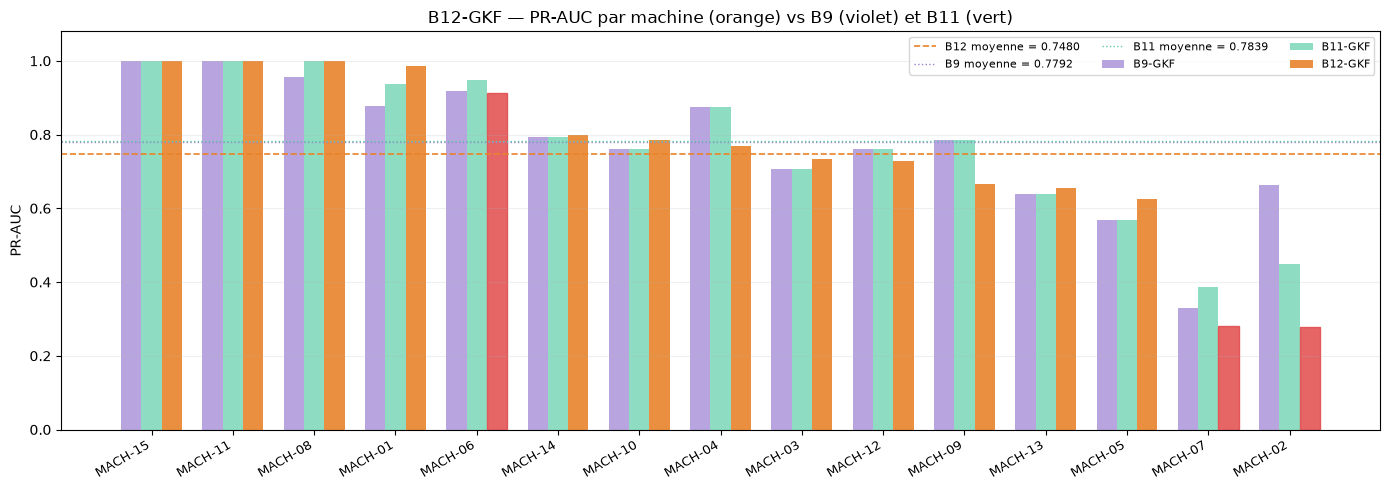

Sauvegardé : b12_comparison.png


In [8]:
display_df = valid.sort_values("pr_auc", ascending=False)

x  = np.arange(len(display_df))
bw = 0.25

fig, ax = plt.subplots(figsize=(14, 5))

bars_b9  = ax.bar(x - bw, display_df["b9"],    width=bw, color="#9B7FD4", alpha=0.7, label="B9-GKF")
bars_b11 = ax.bar(x,      display_df["b11"].fillna(display_df["b9"]),
                           width=bw, color="#5ECFA8", alpha=0.7, label="B11-GKF")
bars_b12 = ax.bar(x + bw, display_df["pr_auc"], width=bw, color="#E8832A", alpha=0.9, label="B12-GKF")

# Colorier en rouge les régressions de B12 vs B11
for i, (idx, row) in enumerate(display_df.iterrows()):
    if pd.notna(row["b11"]) and row["pr_auc"] < row["b11"] - 0.01:
        bars_b12[i].set_color("#E04040")
        bars_b12[i].set_alpha(0.8)

ax.set_xticks(x)
ax.set_xticklabels(display_df["machine"], rotation=30, ha="right", fontsize=9)
ax.set_ylabel("PR-AUC")
ax.set_ylim(0, 1.08)
ax.set_title("B12-GKF — PR-AUC par machine (orange) vs B9 (violet) et B11 (vert)")
ax.axhline(cv_mean, color="#E8832A", linestyle="--", linewidth=1.2,
           label=f"B12 moyenne = {cv_mean:.4f}")
ax.axhline(0.7792, color="#9B7FD4", linestyle=":", linewidth=1,
           label="B9 moyenne = 0.7792")
ax.axhline(0.7839, color="#5ECFA8", linestyle=":", linewidth=1,
           label="B11 moyenne = 0.7839")
ax.legend(fontsize=8, ncol=3)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("b12_comparison.png", dpi=150)
plt.show()
print(f"Sauvegardé : b12_comparison.png")

## 8. Tableau comparatif par machine

In [9]:
print(f"{'Machine':<12} {'B9-GKF':>8} {'B11-GKF':>8} {'B12-GKF':>8} {'Δ vs B9':>9} {'Δ vs B11':>9}")
print("-" * 60)
for _, row in display_df.iterrows():
    b9   = row["b9"]
    b11  = row["b11"] if pd.notna(row["b11"]) else float("nan")
    b12  = row["pr_auc"]
    d9   = f"{b12 - b9:+.4f}" if pd.notna(b9) else "—"
    d11  = f"{b12 - b11:+.4f}" if pd.notna(b11) else "—"
    b11s = f"{b11:.4f}" if pd.notna(b11) else "—"
    print(f"{row['machine']:<12} {b9:>8.4f} {b11s:>8} {b12:>8.4f} {d9:>9} {d11:>9}")

print("-" * 60)
b9_valid = display_df["b9"].mean()
print(f"{'Moyenne':<12} {b9_valid:>8.4f} {'0.7839':>8} {cv_mean:>8.4f} {cv_mean-b9_valid:>+9.4f}")

Machine        B9-GKF  B11-GKF  B12-GKF   Δ vs B9  Δ vs B11
------------------------------------------------------------
MACH-15        1.0000   1.0000   1.0000   +0.0000   +0.0000
MACH-11        1.0000   1.0000   1.0000   +0.0000   +0.0000
MACH-08        0.9550   1.0000   1.0000   +0.0450   +0.0000
MACH-01        0.8780   0.9360   0.9859   +0.1079   +0.0499
MACH-06        0.9170   0.9470   0.9137   -0.0033   -0.0333
MACH-14        0.7930        —   0.7981   +0.0051         —
MACH-10        0.7600        —   0.7850   +0.0250         —
MACH-04        0.8740        —   0.7694   -0.1046         —
MACH-03        0.7070        —   0.7343   +0.0273         —
MACH-12        0.7610        —   0.7280   -0.0330         —
MACH-09        0.7840        —   0.6663   -0.1177         —
MACH-13        0.6390        —   0.6556   +0.0166         —
MACH-05        0.5680        —   0.6263   +0.0583         —
MACH-07        0.3290   0.3870   0.2801   -0.0489   -0.1069
MACH-02        0.6640   0.4490   0.2770